# Emission and Absorption: the Two Ways to Settle One Event

**A tutorial introduction to the mechanism by which the compensated Liouville
algorithm keeps its sea and its body population in balance. Self-contained: it
assumes no prior reading in this project, and builds the signed ensemble, the
sea, and the event from scratch.**

---


## About this notebook

This notebook is a companion rendering of the tutorial above, generated from
two files that remain the canonical sources:

- [`docs/supplement/emission_and_absorption.md`](https://github.com/billpage/wpmw/blob/main/docs/supplement/emission_and_absorption.md) — the tutorial text
- [`src/demo_emission_and_absorption.py`](https://github.com/billpage/wpmw/blob/main/src/demo_emission_and_absorption.py) — the verification script, Parts A-G

Where the two disagree, the note and the script win; this notebook only
reorganises their material for interactive reading and introduces no new
claims.

**What changed in the reorganisation.** The standalone script computes Parts
A-G in that fixed order and draws all four figures only at the end, because
two of the four figures each combine data from two different Parts (the
ledger figure needs Part D *and* Part G; the thermostat figure needs Part E
*and* Part F). This notebook instead follows the tutorial's own narrative
order (§3 → §4 → §5 → §6 → §7 → §8), running each Part's code right where the
tutorial first discusses it, and drawing each two-Part figure once both of
its inputs exist -- which means the ledger and thermostat figures render
slightly after the point where the tutorial first mentions them, not before.
Each such spot is flagged inline. The static output tables and the
pre-rendered figure links that were embedded in the markdown source have
been removed from the prose below in favour of the live cells that
reproduce them, so nothing is shown twice.

**On the numbers.** This demo is fully deterministic (no random sampling),
so a fresh run of the current code should reproduce the figures quoted in
the tutorial, up to the corrections already noted in its own erratum above.
If a live value here were ever to disagree with a value quoted in the
markdown prose, the live value is the current ground truth -- worth raising
directly rather than trusting either number silently.


## 0. What this note is

Section 5.3 of
[`docs/algorithm/compensated_liouville_algorithm.md`](../algorithm/compensated_liouville_algorithm.md)
gives a five-line table naming two realisations of a residual-channel event,
and two more that are excluded. That table is normative and correct and almost
unreadable on first contact. The mechanism it describes has since become
central — it is what makes the sea population an attractor rather than a tuned
constant — and a reader meeting it for the first time deserves better than a
table.

This note is that reader's on-ramp. It is expository, not normative. Where it
and the specification disagree, the specification wins.

Companion code: [`src/demo_emission_and_absorption.py`](../../src/demo_emission_and_absorption.py),
parts A–G. Every number quoted below is an output of that script. A notebook
version of this tutorial, interleaving this text with that script and its
figures, is at [`docs/notebooks/emission_and_absorption.ipynb`](../notebooks/emission_and_absorption.ipynb)
([rendered copy, output branch](https://github.com/billpage/wpmw/blob/output/notebooks/emission_and_absorption.ipynb)).

**Two things this note contributes** beyond exposition, both numerical and both
new:

- **Theorem J1/J2.** The quantity $P = S + N/2$ — bound pairs plus half the
  free bodies — is conserved *exactly* by the event channel, at any absorptive
  fraction, but only **globally**. Cell by cell it is violated by nine orders
  of magnitude more. §5 works out what each half of that means.
Two open items are logged in §12 rather than argued in the body, because
neither belongs in a tutorial: **J-SP1** withdraws support for one existing
explanation of the conjunction cost, and **J-SP2** proposes a change to the
allocation loop of the specification. J-SP2 in particular is a separate
subject and is written as a proposal, not a finding about the ontology.

**A note on metaphor.** An earlier draft of this note leaned on bookkeeping
language — settling a debt, paying in one currency or another. That language is
ontologically wrong here. If the sea is real, the difference between the two
realisations is not a difference in how something is *recorded*; different
things happen to different real objects. The vocabulary below is accordingly
demographic: three populations, births and deaths among them, and an
equilibrium between two opposed processes. The word *ledger* is kept, because
the specification uses it, but it means an inventory of real populations and
not a choice of description.

---

**Erratum: postulate (S) in transport.** `stream()` in
`src/demo_emission_and_absorption.py` advected in $x$ only; the classical
force was extracted by the compensated split and never re-applied, so no
field drifted in $p$. Since x-advection cannot move anything in $p$, a
sea deficit made at a parent momentum row was stranded there for the whole
run. The figures below predate the repair. J1 is unaffected — the global
pair-count residual is $3.5\times10^{-16}$ either way, a $p$-translation
applied identically to all three fields being a redistribution — as is the
first-order independence of $E$ from $N$ in §5.2, whose refinement ratios
remain 2.00 and 2.00. What changes is the sea trace: for the moving packet
the minimum recovers to $0.75\thinspace B$ by the end of the run instead of
draining monotonically to $0.51\thinspace B$.

The kernel construction in this demo was already correct and is the one now
shared by both demos.


## 1. Worlds, and why the ensemble must be signed

Start with the picture the project is committed to. A quantum state is not a
wave; it is a large collection of **worlds**, each a single classical
configuration, each a point $(x, p)$ in phase space. There is no wavefunction
in the ontology. What we call the quantum state is a statement about how the
worlds are distributed, and what we call quantum behaviour is what happens
because worlds interact with each other.

The distribution we want them to reproduce is the Wigner function $W(x,p)$.
And immediately there is a problem: $W$ goes negative. It is not a
probability density, and no collection of counted objects can have a negative
count.

The project's response is to let the ensemble carry a **sign**. There are two
species of world-particle:

- **positons**, carrying $+1$,
- **negatons**, carrying $-1$.

Write $u^{+}(x,p)$ and $u^{-}(x,p)$ for their densities. Then

$$
E \;=\; u^{+} - u^{-}, \qquad N \;=\; u^{+} + u^{-} ,
$$

and the identification is $E = W$. The observable is the **difference** of two
populations. The sum $N$ — how many bodies are actually present — is not
constrained by quantum mechanics at all. Two ensembles with wildly different
$N$ can represent the very same $W$, so long as their difference matches.

That single fact is the seed of everything in this note. Because $E$ is a
difference, there is always more than one way to change it, and the alternatives
are invisible to the observable but very visible to the bookkeeping.

**Minimal and padded ensembles.** The smallest ensemble representing a given
$W$ puts $u^{+} = \max(W, 0)$ and $u^{-} = \max(-W, 0)$, so that in each
cell only one species is present and $N = |E|$. Any number of coincident
$+/-$ pairs can then be added without touching $E$. The ratio

$$
\rho \;=\; N_0 \big/ \textstyle\int |E|
$$

measures how padded a preparation is; $\rho = 1$ is minimal.

---


## 2. The sea

There is a third population, and it is the one that makes the mechanism work.

Consider a positon and a negaton occupying the *same* cell $(x,p)$, bound
together. Its total charge is $+1 - 1 = 0$. It contributes nothing to $E$,
so it is invisible in every observable — it is **dark**. Call it a **neutral
bound pair**, and call the standing population of such pairs the **sea**, with
density $S(x,p)$ and a uniform background level

$$
B \;=\; 2/h ,
$$

two bound pairs per Planck cell. (Why exactly $2/h$ is a separate story told
in [`species_sectors_and_annihilation.md`](../analysis/species_sectors_and_annihilation.md);
for this note only its existence matters.)

It is worth being careful here, because there are *two* dark objects in this
project and they do opposite jobs:

| object | contributes to $E$? | live in the dynamics? |
|---|---|---|
| neutral bound pair (the sea) | no | **yes** — it is the reservoir events draw on |
| crystal shift $c\cdot\mathbb{1}$, $c = 2$ | yes, but inertly | no — provably inert |

The sea is invisible *and* active. That combination is what lets it absorb
bookkeeping that the observable must not see.

**A bound pair is not two world-particles.** This is the point most likely to
trip a careful reader later, so state it now. A bound sea pair is a single
neutral object. Its constituents do not have separate worldlines, separate
momenta, or separate identities while bound. They acquire them at the moment
the pair is broken, and they lose them at the moment two free bodies are bound.
Birth and death, not motion. §9.1 returns to why this matters.

---


### Program structure

Before the tutorial's argument gets going, here is the shape of the code
that verifies it, since the two are read together from here on:

- **`Ledger`** builds the mesh, the compensated-split residual kernel
  `K_res` (the event-generator described in §3), and the classical
  transport operators. Its constructor is where the compensated splitting
  itself happens -- subtracting the discrete classical force from the full
  potential symbol before anything else runs -- so the object already
  *embodies* the "no new force, only new kinematics" claim central to the
  wider project, not just this note.
- **`packet()`** builds the signed initial condition $E = W$ used
  throughout: a single Gaussian wave packet on the Eckart barrier.
- **`channels()`**, the event loop inside `Ledger`, is where §4's two
  realisations actually live in code: the `absorb=True/False` argument
  literally selects between the emissive and absorptive branches, and the
  live `capA`/`capB` partner-availability checks are the code-level version
  of §8's "conjunction cost."
- **`stream()` / `stream3()`** implement the classical transport of
  postulate (S), including the momentum-drift fix described in the erratum
  above.
- **Parts A-G** are the seven falsifiable numerical claims the tutorial
  makes, one function each, matching §11's index table below.
- **`fig_*`** functions draw the four companion figures; two of them each
  draw on two different Parts' data, as noted where they appear below.

The standalone script runs Parts A-G in that fixed order and all four
figures at the end; this notebook reorders the *calls* to match the
tutorial's narrative, without changing any of the function bodies above.


In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

HBAR = 1.0
MU = 1.0
B = 1.0 / (np.pi * HBAR)          # two bound sea pairs per h-cell


def banner(title: str) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


def save_fig(fig, name: str) -> None:
    """Notebook version of the script's ``save_fig``.

    The standalone script writes each figure through ``output_path()`` /
    ``docs_path()`` (see ``wpmwlib/wpmw_utils.py``) so it lands in the
    right place whether it runs in the Claude container, on Kaggle, or
    locally against the ``output``-branch worktree.  Here the notebook
    itself -- once executed -- *is* the persisted artifact (this rendered
    copy is committed to the ``notebooks/`` directory on the ``output``
    branch, exactly parallel to the ``figures/`` convention), so this
    version just displays the figure inline instead of writing a file.
    """
    plt.show()
    plt.close(fig)


def V(r, v0, a):
    return v0 / np.cosh(r / a) ** 2


def dV(r, v0, a):
    return -2.0 * v0 * np.tanh(r / a) / (a * np.cosh(r / a) ** 2)


class Ledger:
    """Eckart barrier, compensated split, three ledger fields."""

    def __init__(self, v0=1.0, a=1.0, n_r=128, r_half=20.0, n_p=64, dp=0.25):
        self.v0, self.a, self.n_p, self.dp = v0, a, n_p, dp
        self.r = -r_half + 2.0 * r_half * np.arange(n_r) / n_r
        self.dr = self.r[1] - self.r[0]
        self.kr = 2.0 * np.pi * np.fft.fftfreq(n_r, d=self.dr)
        self.p = dp * (np.fft.fftfreq(n_p, d=1.0 / n_p).astype(int) + 0.5)
        s = 2.0 * np.pi * np.fft.fftfreq(n_p, d=dp)
        self.y = HBAR * s / 2.0
        self.y_max = float(np.abs(self.y).max())
        self.area = self.dr * self.dp

        rr, yy = self.r[:, None], self.y[None, :]
        xi = np.round(np.fft.fftfreq(n_p, d=1.0) * n_p) * dp
        self.xi = xi
        nyq = n_p // 2

        # the full potential symbol, and the reference symbol i*s
        m_full = (1j / HBAR) * (V(rr + yy, v0, a) - V(rr - yy, v0, a))
        s_sym = np.broadcast_to(s, m_full.shape).copy()
        m_full[:, nyq] = 0.0                  # 4.1, normative
        s_sym[:, nyq] = 0.0

        def first_moment(sym):
            return np.real((xi * np.fft.ifft(sym, axis=-1)).sum(axis=-1))

        # The raised-cosine horizon is applied FIRST, to both symbols.
        # Compensating and then windowing would put the horizon's own first
        # moment back into the residual channel; the order matters.
        w = np.cos(np.pi * self.y / (2.0 * self.y_max)) ** 2
        m_full = m_full * w[None, :]
        s_sym = s_sym * w[None, :]

        # 3.2, normative: the classical force is the kernel's own discrete
        # first moment, not V'(x).  Using V'(x) leaves spurious force in a
        # channel that is specified to carry none.
        self.dv_eff = first_moment(m_full) / first_moment(1j * s_sym)
        m_res = m_full - 1j * self.dv_eff[:, None] * s_sym

        self.k_full = np.fft.ifft(m_res, axis=1)
        self.k = np.real(self.k_full)                      # real, odd in q
        self.sym_e = np.fft.fft(self.k, axis=1)
        self.gamma_tot = np.abs(self.k).sum(axis=1)
        # postulate (S): the classical p-drift, applied by stream() to EVERY
        # field, sea pairs included
        self.cls = 1j * self.dv_eff[:, None] * s[None, :]

    # -- transport -----------------------------------------------------
    def stream(self, f, dt):
        """Classical transport under postulate (S): x-advection at p/mu AND
        the full classical force as a drift in p.

        Omitting the p-drift strands every sea deficit at the momentum row
        where it was made, since x-advection alone never moves anything in p.
        """
        fh = np.fft.fft(f, axis=0)
        fh *= np.exp(-1j * self.kr[:, None] * self.p[None, :] * dt / MU)
        f = np.real(np.fft.ifft(fh, axis=0))
        return np.real(np.fft.ifft(np.fft.fft(f, axis=1)
                                   * np.exp(dt * self.cls), axis=1))

    def stream3(self, up, um, sea, dt):
        """Transport all three fields.  The sea is carried, not pinned, and
        it streams under the classical force exactly as the free bodies do:
        the two members of a sea pair are co-located and share a trajectory,
        and the force is charge-blind, so classical streaming is the unique
        motion that carries the pair without separating it.
        """
        return (self.stream(up, dt), self.stream(um, dt),
                self.stream(sea, dt))

    def qle_step(self, e, dt):
        """Exact mesh reference for E: stream / exact substep / stream."""
        e = self.stream(e, 0.5 * dt)
        e = np.real(np.fft.ifft(np.fft.fft(e, axis=1)
                                * np.exp(dt * self.sym_e), axis=1))
        return self.stream(e, 0.5 * dt)

    # -- the event channel ---------------------------------------------
    def channels(self, up, um, sea, dt, absorb=True, stats=None,
                 clamp=True):
        """One potential substep, tau-leaped over channel pairs (q, -q).

        Each pair is ONE event depositing +1 at one daughter momentum row
        and -1 at the other.  The absorptive process needs a partner of the
        opposite species at BOTH daughters; when supply fails the event
        proceeds emissively instead, breaking a bound sea pair at the parent
        row.  Caps are read live, per the allocation rule.
        """
        n_abs = n_emi = 0.0
        for q in range(1, self.n_p // 2):
            lam = np.abs(self.k[:, q])[:, None]
            if lam.max() < 1e-14:
                continue
            sg = np.sign(self.k[:, q])[:, None]
            for parent, sp in ((up, 1.0), (um, -1.0)):
                D = lam * parent * dt
                if D.max() <= 0.0:
                    continue
                t = np.broadcast_to(sg * sp, D.shape)
                # spectral transport rings, so a cell can carry a small
                # negative population; a negative supply is no supply, and
                # clipping the CAP leaves the ledger arithmetic untouched
                # (clamping the fields themselves would not)
                capA = np.clip(np.where(t > 0, np.roll(um, -q, axis=1),
                                        np.roll(up, -q, axis=1)), 0.0, None)
                capB = np.clip(np.where(t > 0, np.roll(up, q, axis=1),
                                        np.roll(um, q, axis=1)), 0.0, None)
                if absorb:
                    A = np.minimum(D, np.minimum(capA, capB))
                else:
                    A = np.zeros_like(D)
                Em = D - A
                n_abs += float(A.sum())
                n_emi += float(Em.sum())
                if stats is not None:
                    m = D > 1e-15
                    if m.any():
                        w = D[m]
                        fa = np.clip(capA[m] / w, 0.0, 1.0)
                        fb = np.clip(capB[m] / w, 0.0, 1.0)
                        fj = np.clip(np.minimum(capA[m], capB[m]) / w,
                                     0.0, 1.0)
                        # demand-weighted, so a cell with no demand cannot
                        # dominate the average
                        tw = w.sum()
                        stats["w"].append(float(tw))
                        stats["legA"].append(float((fa * w).sum() / tw))
                        stats["legB"].append(float((fb * w).sum() / tw))
                        stats["both"].append(float((fj * w).sum() / tw))

                # absorptive: consume a partner at each daughter, bind at p
                aq, am = np.roll(A, q, axis=1), np.roll(A, -q, axis=1)
                um -= np.where(t > 0, aq, 0.0)
                up -= np.where(t > 0, 0.0, aq)
                up -= np.where(t > 0, am, 0.0)
                um -= np.where(t > 0, 0.0, am)
                sea += A
                # emissive: ionise a bound pair at p, place the children
                eq, em = np.roll(Em, q, axis=1), np.roll(Em, -q, axis=1)
                up += np.where(t > 0, eq, 0.0)
                um += np.where(t > 0, 0.0, eq)
                um += np.where(t > 0, em, 0.0)
                up += np.where(t > 0, 0.0, em)
                sea -= Em

                if clamp:
                    np.maximum(up, 0.0, out=up)
                    np.maximum(um, 0.0, out=um)
        return up, um, sea, n_abs, n_emi

    @staticmethod
    def recombine(up, um, sea, kappa, dt):
        """Bilinear sink: removes coincident +/- pairs back into the sea.

        N^2 - E^2 = 4 u+ u-, so this is mass action in the two species.
        """
        if kappa == 0.0:
            return up, um, sea
        d = np.minimum(np.minimum(up, um), kappa * up * um * dt)
        return up - d, um - d, sea + d

    def prepare(self, e0, rho):
        """Minimal ensemble padded to N0/|E| = rho.  E is untouched."""
        up = np.maximum(e0, 0.0).copy()
        um = np.maximum(-e0, 0.0).copy()
        pad = 0.5 * (rho - 1.0) * np.abs(e0)
        return up + pad, um + pad, np.full_like(e0, B)

In [2]:
def packet(run, r0=-6.0, p0=1.2, sr=1.0, sp=0.35):
    R, P = run.r[:, None], run.p[None, :]
    e0 = np.exp(-(R - r0) ** 2 / (2 * sr ** 2)) \
        * np.exp(-(P - p0) ** 2 / (2 * sp ** 2))
    return e0 / e0.sum()

run = Ledger()

## 3. What an event is

Worlds move classically between events: $\dot{x} = p/\mu$, $\dot{p} = -V'(x)$.
Everything non-classical happens at events.

An event is a **momentum transfer between two worlds**, and the compensated
splitting of the algorithm arranges that the classical force has already been
removed, so the events carry only the residual — the genuinely quantum part.
The rate field $K_{\mathrm{res}}(x, \xi_q)$ that governs them has three
properties, all verified in part A of the demo, executed live below.

The oddness is the important one. The channel at $+\xi_q$ and the channel at
$-\xi_q$ carry exactly equal and opposite weight. On the barrier flank, at
$r = -1.56$ and $q = 3$, the two legs come out numerically equal
and opposite (confirmed live below).

These are **not two events**. They are the two **legs of one event**. An event
picks a parent momentum row $p$ and deposits

- $+1$ at the daughter row $p + \xi_q$,
- $-1$ at the daughter row $p - \xi_q$,

and the two legs are co-located: same $x$, symmetric in momentum about the
parent. The QLE fixes this deposition completely. Nothing in this note changes
what is deposited. Everything in this note is about *how the deposit is paid
for*.

---


In [3]:
def part_a(run):
    banner("A. What an event is: one event, two legs of opposite sign")
    k = run.k
    q = 3
    m = int(np.argmin(np.abs(run.r + 1.5)))       # on the emitting flank
    imag = float(np.abs(np.imag(run.k_full)).max()
                 / np.abs(run.k_full).max())
    odd = float(np.abs(k[:, 1:] + k[:, ::-1][:, :-1]).max())
    print(f"   max |Im K_res| / max |K_res|        {imag:.3e}")
    print(f"   max |K_q + K_(-q)|   (oddness)      {odd:.3e}")
    scale = float(np.abs(k).max())
    print(f"   sum_q K_res          (worlds)       "
          f"{float(np.abs(k.sum(axis=1)).max()) / scale:.3e}")
    print(f"   sum_q xi_q K_res     (momentum)     "
          f"{float(np.abs((run.xi * k).sum(axis=1)).max()) / scale:.3e}")
    print()
    print("   K_res is real and odd, so the channels q and -q carry equal and")
    print("   opposite weight.  They are not two channels: they are the two")
    print("   legs of one event, which deposits +1 at p + xi_q and -1 at")
    print(f"   p - xi_q.  At r = {run.r[m]:+.2f} on the flank, channel "
          f"q = {q}:\n   K = {k[m, q]:+.5f},   K_(-q) = {k[m, -q]:+.5f}")
    return odd

odd = part_a(run)


A. What an event is: one event, two legs of opposite sign
   max |Im K_res| / max |K_res|        6.872e-17
   max |K_q + K_(-q)|   (oddness)      1.110e-16
   sum_q K_res          (worlds)       2.063e-16
   sum_q xi_q K_res     (momentum)     1.857e-15

   K_res is real and odd, so the channels q and -q carry equal and
   opposite weight.  They are not two channels: they are the two
   legs of one event, which deposits +1 at p + xi_q and -1 at
   p - xi_q.  At r = -1.56 on the flank, channel q = 3:
   K = -0.13064,   K_(-q) = +0.13064


## 4. The two realisations

Here is the whole idea, and it takes three sentences.

$E$ is a difference. So "deposit $+1$ here" has two readings: **add a
positon**, or **remove a negaton**. They are indistinguishable in the
observable and opposite in every other book.

Applying that to both legs at once gives the two realisations. The
specification's own verbs are the right ones, and they are the verbs of
ionisation chemistry rather than of accounting:

**Emissive — a bound pair is *ionised*.** Add a positon at $p + \xi_q$ and a
negaton at $p - \xi_q$. The two new bodies come from somewhere: a bound sea
pair at the parent row $p$ comes apart, and its two constituents are the two
new bodies. One bound pair is consumed; two free bodies enter circulation.

**Absorptive — two free bodies are *bound*.** Remove a negaton at
$p + \xi_q$ and a positon at $p - \xi_q$. The two removed bodies do not
vanish; they bind into a neutral pair at the parent row $p$. Two free bodies
leave circulation; one bound pair is created.

These are the two directions of a single exchange between the bound population
and the free one — dissociation and recombination, as in an ionisation
equilibrium. Both run forward in time. Neither is the other's time-reverse:
time reversal would flip every momentum, and nothing here does. They are
opposed in the sense that a forward and a reverse reaction are opposed, which
is why §7 can be an equilibrium argument.

The figure produced below is the same picture with the arrows reversed, because the exchange
is the same exchange run the other way.


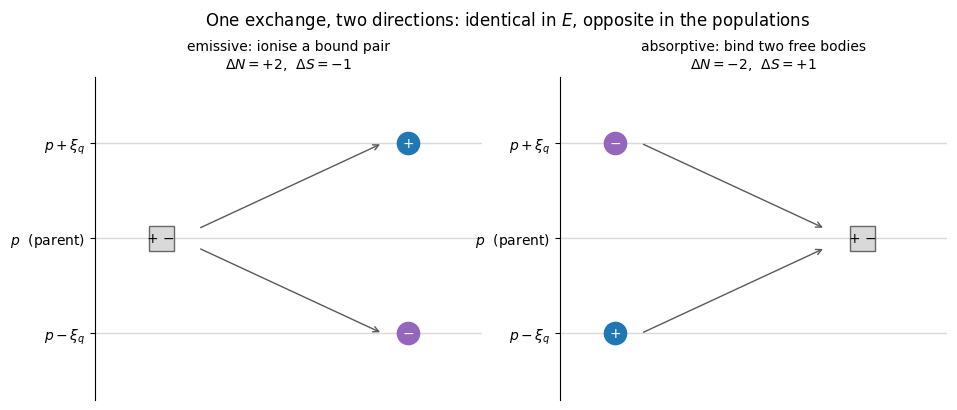

In [4]:
def fig_realisations(run):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    for k, (tag, sign) in enumerate((("emissive: ionise a bound pair", +1),
                                     ("absorptive: bind two free bodies",
                                      -1))):
        a = ax[k]
        for y in (-1, 0, 1):
            a.axhline(y, color="0.85", lw=1, zorder=0)
        if sign > 0:
            a.plot([0.18], [0], "s", ms=18, mfc="0.85", mec="0.4", zorder=3)
            a.text(0.18, 0, "+ −", ha="center", va="center", fontsize=10)
            a.annotate("", xy=(0.78, 1), xytext=(0.28, 0.1),
                       arrowprops=dict(arrowstyle="->", color="0.35"))
            a.annotate("", xy=(0.78, -1), xytext=(0.28, -0.1),
                       arrowprops=dict(arrowstyle="->", color="0.35"))
            a.plot([0.85], [1], "o", ms=16, mfc="C0", mec="C0", zorder=3)
            a.text(0.85, 1, "+", ha="center", va="center", color="w")
            a.plot([0.85], [-1], "o", ms=16, mfc="C4", mec="C4", zorder=3)
            a.text(0.85, -1, "−", ha="center", va="center", color="w")
            a.set_title(tag + "\n$\\Delta N = +2$,  $\\Delta S = -1$",
                        fontsize=10)
        else:
            a.plot([0.15], [1], "o", ms=16, mfc="C4", mec="C4", zorder=3)
            a.text(0.15, 1, "−", ha="center", va="center", color="w")
            a.plot([0.15], [-1], "o", ms=16, mfc="C0", mec="C0", zorder=3)
            a.text(0.15, -1, "+", ha="center", va="center", color="w")
            a.annotate("", xy=(0.72, 0.1), xytext=(0.22, 1),
                       arrowprops=dict(arrowstyle="->", color="0.35"))
            a.annotate("", xy=(0.72, -0.1), xytext=(0.22, -1),
                       arrowprops=dict(arrowstyle="->", color="0.35"))
            a.plot([0.82], [0], "s", ms=18, mfc="0.85", mec="0.4", zorder=3)
            a.text(0.82, 0, "+ −", ha="center", va="center", fontsize=10)
            a.set_title(tag + "\n$\\Delta N = -2$,  $\\Delta S = +1$",
                        fontsize=10)
        a.set_yticks([-1, 0, 1])
        a.set_yticklabels([r"$p - \xi_q$", r"$p$  (parent)",
                           r"$p + \xi_q$"])
        a.set_xticks([])
        a.set_xlim(0, 1.05)
        a.set_ylim(-1.7, 1.7)
        for sp in ("top", "right", "bottom"):
            a.spines[sp].set_visible(False)
    fig.suptitle("One exchange, two directions: identical in $E$, "
                 "opposite in the populations", y=1.04)
    save_fig(fig, "emission_absorption_realisations.png")

fig_realisations(run)

That phase-space cartoon has one serious defect: it invites the reader to see
the diagonal arrows as *paths*, along which something travels from the parent
momentum row to the daughters. Nothing travels. The honest picture is in
space-time, where all three populations are visible as worldlines and a
momentum is a **slope**, as the figure generated below makes precise.


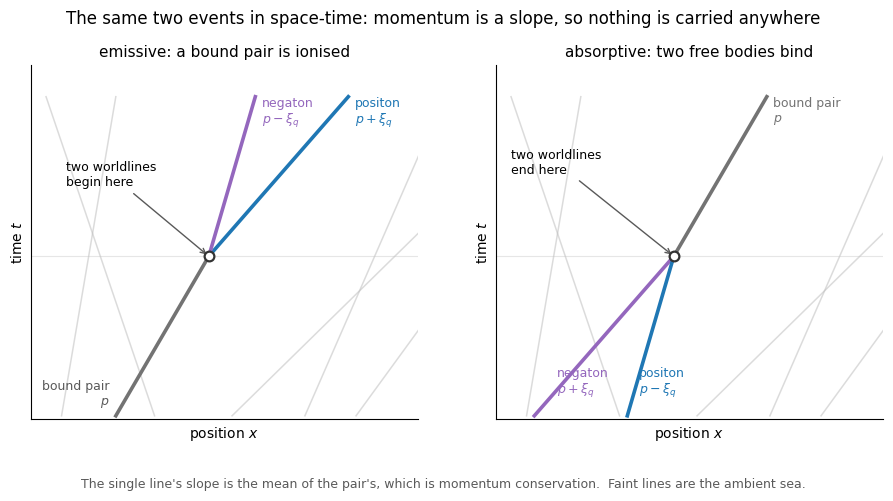

In [5]:
def fig_worldlines():
    """Space-time worldlines for all three species, both directions.

    The phase-space cartoon is easy to misread as a body being carried
    between momentum rows.  In space-time there is no carrying: two
    worldlines begin at a point, or two end at one.  A momentum is a SLOPE
    here, so momentum conservation is the geometric statement that the
    single line's slope is the mean of the pair's.
    """
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
    t_ev, sl_p, sl_m, sl_0 = 0.5, 1.8, 0.6, 1.2

    for k, emissive in enumerate((True, False)):
        a = ax[k]
        # the ambient sea: real, everywhere, at every momentum
        for x0, sl in ((-0.95, 0.35), (0.15, 2.1), (0.62, 0.9),
                       (-0.35, -0.7), (0.95, 1.5)):
            a.plot([x0, x0 + sl], [0, 1], color="0.75", lw=1.1,
                   alpha=.55, zorder=1)
        if emissive:
            a.plot([-sl_0 * t_ev, 0], [0, t_ev], color="0.45", lw=2.6,
                   zorder=3)
            a.plot([0, sl_p * (1 - t_ev)], [t_ev, 1], color="C0", lw=2.6,
                   zorder=3)
            a.plot([0, sl_m * (1 - t_ev)], [t_ev, 1], color="C4", lw=2.6,
                   zorder=3)
            a.annotate("two worldlines\nbegin here",
                       xy=(0, t_ev), xytext=(-0.92, 0.72), fontsize=9,
                       arrowprops=dict(arrowstyle="->", color="0.35",
                                       lw=1))
            a.text(sl_p * (1 - t_ev) + .04, 1.0, "positon\n$p + \\xi_q$",
                   color="C0", fontsize=9, va="top")
            a.text(sl_m * (1 - t_ev) + .04, 1.0, "negaton\n$p - \\xi_q$",
                   color="C4", fontsize=9, va="top")
            a.text(-sl_0 * t_ev - .04, 0.02, "bound pair\n$p$",
                   color="0.35", fontsize=9, ha="right", va="bottom")
            a.set_title("emissive: a bound pair is ionised", fontsize=11)
        else:
            a.plot([-sl_p * t_ev, 0], [0, t_ev], color="C4", lw=2.6,
                   zorder=3)
            a.plot([-sl_m * t_ev, 0], [0, t_ev], color="C0", lw=2.6,
                   zorder=3)
            a.plot([0, sl_0 * (1 - t_ev)], [t_ev, 1], color="0.45", lw=2.6,
                   zorder=3)
            a.annotate("two worldlines\nend here",
                       xy=(0, t_ev), xytext=(-1.05, 0.76), fontsize=9,
                       arrowprops=dict(arrowstyle="->", color="0.35",
                                       lw=1))
            a.text(-sl_p * t_ev + sl_p * .06 + .04, 0.05,
                   "negaton\n$p + \\xi_q$",
                   color="C4", fontsize=9, ha="left", va="bottom")
            a.text(-sl_m * t_ev + sl_m * .06 + .04, 0.05,
                   "positon\n$p - \\xi_q$",
                   color="C0", fontsize=9, ha="left", va="bottom")
            a.text(sl_0 * (1 - t_ev) + .04, 1.0, "bound pair\n$p$",
                   color="0.45", fontsize=9, va="top")
            a.set_title("absorptive: two free bodies bind", fontsize=11)

        a.plot([0], [t_ev], "o", ms=7, mfc="w", mec="0.2", mew=1.6,
               zorder=4)
        a.axhline(t_ev, color="0.9", lw=.8, zorder=0)
        a.set_xlim(-1.15, 1.35)
        a.set_ylim(-0.01, 1.1)
        a.set_xlabel("position $x$")
        a.set_ylabel("time $t$")
        a.set_xticks([])
        a.set_yticks([])
        for sp in ("top", "right"):
            a.spines[sp].set_visible(False)

    fig.suptitle("The same two events in space-time: momentum is a slope, "
                 "so nothing is carried anywhere", y=1.0)
    fig.text(0.5, -0.04, "The single line's slope is the mean of the "
                         "pair's, which is momentum conservation.  Faint "
                         "lines are the ambient sea.",
             ha="center", fontsize=9, color="0.35")
    save_fig(fig, "emission_absorption_worldlines.png")

fig_worldlines()

Read the left panel. A bound pair moves classically with slope $p$. At the
event its worldline **ends**, and two new worldlines **begin** at the same
space-time point, with slopes $p + \xi_q$ and $p - \xi_q$. In the right
panel two worldlines end and one begins. The faint lines are the ambient sea:
real, present everywhere, at every momentum.

Momentum conservation is now a geometric statement — the single line's slope is
the mean of the pair's — and the thing that looked like a jump between momentum
rows has become a fork. §9 makes that argument properly, since it is the
objection most likely to stop a careful reader.


In [6]:
def part_b(run):
    banner("B. The two realisations: same E, opposite ledger")
    e0 = packet(run)
    rows = []
    for tag, absorb in (("emissive   (pair -> two)", False),
                        ("absorptive (two -> pair)", True)):
        up, um, sea = run.prepare(e0, 6.0)
        e_pre = up - um
        n_pre, s_pre = float((up + um).sum()), float(sea.sum())
        up, um, sea, a, em = run.channels(up, um, sea, 0.02, absorb=absorb)
        nev = a + em
        rows.append((tag, nev, a / nev,
                     float(np.linalg.norm((up - um) - e_pre)),
                     float((up + um).sum()) - n_pre,
                     float(sea.sum()) - s_pre))
    print(f"   {'process':<25}{'events':>10}{'f':>8}"
          f"{'|dE| moved':>13}{'dN':>10}{'dS':>10}")
    for tag, nev, f, de, dn, ds in rows:
        print(f"   {tag:<25}{nev:>10.5f}{f:>8.3f}{de:>13.3e}"
              f"{dn:>+10.5f}{ds:>+10.5f}")
    print()
    print("   The two directions move E by the same amount to within the")
    print("   sequential-allocation difference of the tau-leap; Part G shows")
    print("   that residue is O(dt).  What they do NOT share is the ledger:")
    print("   dN and dS have opposite signs, and the ratio dN/dS is exactly")
    print("   -2 either way -- one bound pair for two free bodies.")
    for tag, nev, f, de, dn, ds in rows:
        if abs(ds) > 1e-12:
            print(f"     {tag}: dN/dS = {dn / ds:+.6f}")
    return rows

rows_b = part_b(run)


B. The two realisations: same E, opposite ledger
   process                      events       f   |dE| moved        dN        dS
   emissive   (pair -> two)    0.00560   0.000    9.577e-06  +0.01121  -0.00560
   absorptive (two -> pair)    0.00558   0.924    9.664e-06  -0.00947  +0.00473

   The two directions move E by the same amount to within the
   sequential-allocation difference of the tau-leap; Part G shows
   that residue is O(dt).  What they do NOT share is the ledger:
   dN and dS have opposite signs, and the ratio dN/dS is exactly
   -2 either way -- one bound pair for two free bodies.
     emissive   (pair -> two): dN/dS = -2.000000
     absorptive (two -> pair): dN/dS = -2.000000


The demo runs both realisations on the same state (part B), executed live
below.

Read the columns. The amount of $E$ moved agrees to under one per cent — the
residue is the sequential-allocation difference of the tau-leap, and §11 shows
it is $O(\Delta t)$ and converges away. The ledger columns do not agree at
all: $\Delta N$ and $\Delta S$ have opposite signs. And the ratio
$\Delta N / \Delta S = -2$ is exact in both cases.

That $-2$ is the stoichiometry of the exchange — one bound pair for two free
bodies — and it is the hinge of everything that follows.

**Vocabulary.** The specification calls this a *jump* — a mediated transfer, in
which no body's momentum changes discontinuously. It reserves *hop* for the
excluded variant in which a body is physically moved between momentum rows.
§10.

---


## 5. Three populations, and the one identity

Three populations are now in play: the bound pairs $S$, the free bodies
$N$, and the signed difference $E$. It is tempting to think of these as
three independent stocks that must each be kept in balance. They are not.

### 5.1 Theorem J1: the pair count is conserved

Every event does one of exactly two things:

- emissive: $\Delta N = +2$, $\Delta S = -1$,
- absorptive: $\Delta N = -2$, $\Delta S = +1$.

So define

$$
P \;=\; S \;+\; N/2 .
$$

Then $\Delta P = 1 - 1 = 0$ for an emissive event and $\Delta P = -1 + 1 = 0$
for an absorptive one. **The event channel cannot change $P$ at all**, no
matter what mixture of the two it uses.

Part D verifies this in a full streaming run with the bilinear recombination
sink also active (the `clamp` column is explained in §12) — executed live
below, where the full table (clamp on *and* off, together with the local
figures used in §12) appears in one place.

Machine precision, and — note this — at $f = 0.71$ just as much as at
$f = 0.43$. The identity is not a property of the equilibrium. It holds
everywhere.

This is worth pausing on because it simplifies the picture enormously. There is
**one** conserved quantity here, the total pair count, counting a bound pair as
one and two free bodies as one. Emission and absorption neither create nor
destroy pairs; they only move them across the bound/free boundary. The
absorptive fraction $f$ is not a rate constant in a two-population system. It
is the **partition parameter** of a single population — what fraction of a
fixed stock is currently in circulation rather than in the reservoir.

That in turn makes the specification's ledger identity almost obvious rather
than surprising: if a single number controls the partition, then of course one
value of it holds both halves stationary at once.


In [7]:
def part_d(run):
    banner("D. J1 and J2: the pair count is conserved globally, not locally")
    e0 = packet(run)

    print("   J1.  P = S + N/2 across the event channel and the bilinear")
    print("   sink, per substep, in a streaming run.  'clamp' is the")
    print("   u+ , u- >= 0 clamp the specification places inside the")
    print("   allocation loop.")
    print(f"   {'rho':>6}{'clamp':>8}{'f':>9}{'rel |dP| per step':>19}"
          f"{'max |du+ - du-|':>18}")
    glob = []
    for rho in (1.0, 5.0, 20.0):
        for clamp in (False, True):
            up, um, sea = run.prepare(e0, rho)
            p0 = float(sea.sum() + 0.5 * (up + um).sum())
            worst = opp = 0.0
            na = ne = 0.0
            dt = 0.01
            for _ in range(300):
                up, um, sea = run.stream3(up, um, sea, .5 * dt)
                before = float(sea.sum() + 0.5 * (up + um).sum())
                pp, pm = float(up.sum()), float(um.sum())
                up, um, sea, a_, em = run.channels(up, um, sea, dt,
                                                   clamp=clamp)
                up, um, sea = run.recombine(up, um, sea, 50.0, dt)
                worst = max(worst, abs(
                    float(sea.sum() + 0.5 * (up + um).sum()) - before))
                opp = max(opp, abs((float(up.sum()) - pp)
                                   - (float(um.sum()) - pm)))
                up, um, sea = run.stream3(up, um, sea, .5 * dt)
                na += a_
                ne += em
            f = na / (na + ne)
            glob.append((rho, clamp, f, worst / p0, opp))
            print(f"   {rho:>6.1f}{str(clamp):>8}{f:>9.4f}"
                  f"{worst / p0:>19.3e}{opp:>18.3e}")

    print()
    print("   Clamp off, the identity is exact: an event moves N by 2 and S")
    print("   by 1 in opposite senses, so P cannot move at all.  Clamp on it")
    print("   holds only to 1e-7, and the two species stop moving together.")
    print("   The clamp is the only operation here that can break J1; the")
    print("   note records the diagnosis and a proposed change under open")
    print("   item J-SP2 rather than in the tutorial body.")

    print()
    print("   J2, local.  The same quantity, cell by cell, one substep.")
    up, um, sea = run.prepare(e0, 6.0)
    pre = sea + 0.5 * (up + um)
    up, um, sea, _, _ = run.channels(up, um, sea, 0.02, clamp=False)
    d = (sea + 0.5 * (up + um)) - pre
    loc, tot = float(np.abs(d).max()), float(abs(d.sum()))
    print(f"   max per-cell |dP|                    {loc:.3e}")
    print(f"   |sum over cells of dP|               {tot:.3e}")
    print(f"   ratio                                "
          f"{loc / max(tot, 1e-300):.1e}")
    print()
    print("   An event debits the sea at the PARENT momentum row and credits")
    print("   bodies at the two DAUGHTER rows, so pair count flows between")
    print("   rows.  P is a global bookkeeping identity, not a local one, and")
    print("   no argument that counts degrees of freedom from P constrains")
    print("   the local dynamics.")
    return glob, loc, tot

glob, loc, tot = part_d(run)


D. J1 and J2: the pair count is conserved globally, not locally
   J1.  P = S + N/2 across the event channel and the bilinear
   sink, per substep, in a streaming run.  'clamp' is the
   u+ , u- >= 0 clamp the specification places inside the
   allocation loop.
      rho   clamp        f  rel |dP| per step   max |du+ - du-|


      1.0   False   0.4384          3.487e-16         6.539e-16


      1.0    True   0.4408          1.806e-07         2.020e-04


      5.0   False   0.6410          3.485e-16         1.332e-15


      5.0    True   0.6449          1.810e-07         2.878e-04


     20.0   False   0.7239          5.212e-16         2.665e-15


     20.0    True   0.7274          2.468e-07         3.012e-04

   Clamp off, the identity is exact: an event moves N by 2 and S
   by 1 in opposite senses, so P cannot move at all.  Clamp on it
   holds only to 1e-7, and the two species stop moving together.
   The clamp is the only operation here that can break J1; the
   note records the diagnosis and a proposed change under open
   item J-SP2 rather than in the tutorial body.

   J2, local.  The same quantity, cell by cell, one substep.
   max per-cell |dP|                    1.162e-04
   |sum over cells of dP|               2.798e-14
   ratio                                4.2e+09

   An event debits the sea at the PARENT momentum row and credits
   bodies at the two DAUGHTER rows, so pair count flows between
   rows.  P is a global bookkeeping identity, not a local one, and
   no argument that counts degrees of freedom from P constrains
   the local dynamics.


### 5.2 Theorem J2: but only globally

Now the correction, and it matters.

An event debits the sea at the **parent** row $p$ and credits bodies at the
**daughter** rows $p \pm \xi_q$. Those are different cells. So pair count
*flows* between momentum rows, and the identity of §5.1 is a statement about
the sum over all cells, not about any one of them.

Part D, same substep, measured cell by cell — see the same live cell above.

Nine orders of magnitude. Locally the sea and the bodies are two genuinely
independent fields with transport between them.

(The combined ledger figure appears further below, once Part G's data —
used in its right-hand panel — has also been computed; see the program
note after §7.)

The practical consequence is a warning. It is tempting to argue from J1 that
the system has only one degree of freedom, and therefore that certain
behaviours — oscillations, travelling structure in the sea — are impossible.
**That argument is invalid.** J1 constrains the totals and says nothing about
the local dynamics, which has two fields and can do what two-field systems do.
The local sea level is a live dynamical variable.

---


## 6. Why the fraction is one half

Look again at what an event does to the two species *separately*.

An emissive event creates one positon **and** one negaton. An absorptive event
destroys one positon **and** one negaton. Neither ever moves one species
without moving the other by the same amount in the same direction. Part C, executed live below, confirms this.

So over $n$ events with absorptive fraction $f$,

$$
\Delta N \;=\; 2\thinspace (1 - 2f)\thinspace n , \qquad
\Delta S \;=\; (2f - 1)\thinspace n .
$$

Both vanish at $f = 1/2$ and at no other value. The reasoning needs nothing
about the potential, the reach, the packet, or the depth of the sea. It is
arithmetic on $\pm 1$.

The most useful way to say it: whichever species is locally in the **minority**
gains exactly one body per emissive event and loses exactly one per absorptive
event. Its population is stationary precisely when the two are equally
frequent.

---


In [8]:
def part_c(run):
    banner("C. Both species move together, +1 or -1 each per event")
    e0 = packet(run)
    up, um, sea = run.prepare(e0, 6.0)
    worst = 0.0
    dn_tot = na = ne = 0.0
    for _ in range(40):
        pp, pm = float(up.sum()), float(um.sum())
        up, um, sea, a, em = run.channels(up, um, sea, 0.02)
        d_p, d_m = float(up.sum()) - pp, float(um.sum()) - pm
        worst = max(worst, abs(d_p - d_m))
        dn_tot += d_p + d_m
        na += a
        ne += em
    f = na / (na + ne)
    pred = 2.0 * (1.0 - 2.0 * f) * (na + ne)
    print(f"   max |du+ - du-| over 40 substeps     {worst:.3e}")
    print(f"   measured absorptive fraction f       {f:.6f}")
    print(f"   measured dN                          {dn_tot:+.6f}")
    print(f"   predicted 2(1 - 2f) n_ev             {pred:+.6f}")
    print(f"   residual                             {dn_tot - pred:+.3e}")
    print()
    print("   The two species are never moved separately.  An emissive event")
    print("   makes one positon and one negaton; an absorptive event destroys")
    print("   one of each.  So whichever species is locally in the minority")
    print("   gains one body per emissive event and loses one per absorptive")
    print("   event, and its population is stationary exactly at f = 1/2.")
    return worst

worst = part_c(run)


C. Both species move together, +1 or -1 each per event


   max |du+ - du-| over 40 substeps     1.332e-15
   measured absorptive fraction f       0.854768
   measured dN                          -0.299913
   predicted 2(1 - 2f) n_ev             -0.299913
   residual                             +1.471e-14

   The two species are never moved separately.  An emissive event
   makes one positon and one negaton; an absorptive event destroys
   one of each.  So whichever species is locally in the minority
   gains one body per emissive event and loses one per absorptive
   event, and its population is stationary exactly at f = 1/2.


## 7. Why it finds one half by itself

Nothing so far explains why $f$ *should* be one half. It explains what
happens if it is. The mechanism that gets it there is the part worth
understanding, and it is not a control law.

The rule the algorithm follows is local and blind:

> Settle absorptively if a partner of the right species happens to be sitting
> at both daughter rows. Otherwise settle emissively.

Nothing anywhere measures $f$, targets $f$, or adjusts anything to reach
$f = 1/2$. And yet:

- absorption **consumes** minority-species bodies — that is what "remove a
  partner" means;
- emission **produces** them — every emissive event makes one of each species,
  and where the majority is already abundant it is the minority that has been
  added to;
- so a shortage of minority bodies forces emission, which manufactures the very
  thing that was short, and an abundance permits absorption, which eats it.

A thermostat, built out of nothing but supply. If the mix runs too emissive,
bodies accumulate, partners become easy to find, and $f$ rises. If it runs too
absorptive, bodies drain, partners become scarce, and $f$ falls. The fixed
point is where production equals consumption, which by §6 is $f = 1/2$.

The claim that this is genuinely a *local* mechanism, and not something the packet's motion through the potential is secretly arranging, can be tested.
Clock the relaxation against **cumulative events** rather than time,
and run it in four regimes whose event rates differ by a factor of fifteen —
the packet parked on either emitting lobe, parked in a quiet region, and moving
freely (part E, executed live below).


In [9]:
def part_e(run):
    banner("E. The thermostat: f relaxes on the event clock, not the wall clock")
    targets = [1.0, 2.0, 5.0, 10.0, 20.0, 40.0]
    cases = [("parked r = -1.5 (lobe II) ", -1.5, False, 0.02, 4000),
             ("parked r = +1.5 (lobe III)", 1.5, False, 0.02, 4000),
             ("parked r = -6   (quiet)   ", -6.0, False, 0.05, 4000),
             ("moving  r = -6            ", -6.0, True, 0.01, 2000)]
    print(f"   {'packet':<28}{'t_end':>8}"
          + "".join(f"{t:>8.0f}" for t in targets))
    traces = []
    for tag, r0, moving, dt, mx in cases:
        e0 = packet(run, r0=r0)
        up, um, sea = run.prepare(e0, 20.0)
        cum = 0.0
        rows = []
        for k in range(mx):
            if moving:
                up, um, sea = run.stream3(up, um, sea, .5 * dt)
            up, um, sea, a, em = run.channels(up, um, sea, dt)
            if moving:
                up, um, sea = run.stream3(up, um, sea, .5 * dt)
            nev = a + em
            if nev <= 0.0:
                continue
            cum += nev
            rows.append((cum, a / nev))
            if cum > 45.0:
                break
        rows = np.array(rows)
        vals = []
        for t in targets:
            i = int(np.searchsorted(rows[:, 0], t))
            vals.append(rows[i, 1] if i < len(rows) else np.nan)
        traces.append((tag, rows))
        print(f"   {tag:<28}{(k + 1) * dt:>8.1f}"
              + "".join(f"{v:>8.4f}" if np.isfinite(v) else "      --"
                        for v in vals))
    print()
    print("   Gamma differs by a factor of fifteen across these rows and the")
    print("   packet is parked in three of them, yet the relaxation collapses")
    print("   onto one curve in the event clock.  Transport sets how fast the")
    print("   events happen and nothing else; the regulation is local, blind")
    print("   and event-by-event.")
    return traces

traces = part_e(run)


E. The thermostat: f relaxes on the event clock, not the wall clock
   packet                         t_end       1       2       5      10      20      40


   parked r = -1.5 (lobe II)       10.4  0.8861  0.8419  0.7646  0.5960  0.5241  0.5034


   parked r = +1.5 (lobe III)      10.4  0.8875  0.8384  0.7550  0.6061  0.5200  0.5019


   parked r = -6   (quiet)        187.0  0.8129  0.7756  0.6846  0.6069  0.5404  0.5162


   moving  r = -6                  10.1  0.8144  0.7736  0.7163  0.6747  0.6617  0.7462

   Gamma differs by a factor of fifteen across these rows and the
   packet is parked in three of them, yet the relaxation collapses
   onto one curve in the event clock.  Transport sets how fast the
   events happen and nothing else; the regulation is local, blind
   and event-by-event.


All four collapse onto one curve. The wall-clock times differ by a factor of
nineteen; the event-clock trajectories are the same. Transport sets how *fast*
events happen and contributes nothing else. The regulation is event by event.

(The thermostat figure's left panel is this event-clock trace; its right
panel is Part F's conjunction cost from §8 below, so the rendered figure
itself appears once both are in hand — see the program note after §8.)

Every one of these runs starts at $\rho = 20$, badly over-padded, with
$f$ near $0.88$. None is told where to go. All arrive.

---


## 8. Why it stops just short

**Correction, and a narrowing of what this section claims.** Two things have
since changed under it. First, the shortfall quoted throughout the project was
measured with a windowed estimator that phase-samples the packet's own
oscillation; Theorem S7 gives an exact window-free alternative. Second, the
reach ladder varied the horizon by refining $\Delta p$, which in this code
also refines the packet's resolution in momentum — one knob, two effects. With
both corrected (Part J of
[`../analysis/sea_population_equilibrium.md`](../analysis/sea_population_equilibrium.md))
the shortfall falls monotonically towards zero as the horizon opens. So the
conjunction cost below sets the *rate of approach* to one half at finite
reach. It is not a floor, and the attractor is not below one half in the
limit. A further caution: at coarse reach some of the measured cost is not
conjunction at all but the negative-cap leakage diagnosed in J-SP2 below,
which makes the per-leg figures unreliable exactly where the cost looks
largest.

The measured attractor sits slightly *below* one half at any finite reach, and
the shortfall narrows as the coherence reach grows. The reason is in the word
"both."

An absorptive event needs a partner at **both** daughter rows simultaneously,
because §10 forbids realising the two legs at once. Part F, executed live below, measures how often each leg alone
could be satisfied, and how often both can be at once.


In [10]:
def part_f(run):
    banner("F. The conjunction cost: why the attractor sits below 1/2")
    e0 = packet(run)
    rows = []
    for rho in (3.0, 10.0, 20.0):
        up, um, sea = run.prepare(e0, rho)
        st = {"legA": [], "legB": [], "both": [], "w": []}
        dt = 0.01
        na = ne = 0.0
        for _ in range(400):
            up, um, sea = run.stream3(up, um, sea, .5 * dt)
            up, um, sea, a, em = run.channels(up, um, sea, dt, stats=st)
            up, um, sea = run.stream3(up, um, sea, .5 * dt)
            na += a
            ne += em
        wt = np.array(st["w"])
        a_, b_, j_ = (float(np.average(st["legA"], weights=wt)),
                      float(np.average(st["legB"], weights=wt)),
                      float(np.average(st["both"], weights=wt)))
        rows.append((rho, a_, b_, j_, a_ * b_, na / (na + ne)))
    print(f"   {'rho':>6}{'leg A':>9}{'leg B':>9}{'both':>9}"
          f"{'A x B':>9}{'f':>9}")
    for r in rows:
        print(f"   {r[0]:>6.1f}{r[1]:>9.3f}{r[2]:>9.3f}{r[3]:>9.3f}"
              f"{r[4]:>9.3f}{r[5]:>9.3f}")
    print()
    print("   'both' is the fraction of demand that finds a partner at BOTH")
    print("   daughters at once.  Each leg alone is satisfied about four")
    print("   times in five; requiring both at once drops that to about two")
    print("   in three.  Absorption is rationed by the harder of the two")
    print("   legs, and that gap is the conjunction cost -- the reason the")
    print("   attractor sits a little under 1/2 rather than exactly on it.")
    print()
    print("   Note what this does NOT show.  The joint availability is close")
    print("   to the product of the two single-leg figures, sitting slightly")
    print("   below it at rho = 3 and slightly above at rho = 10 and 20.")
    print("   This diagnostic gives no evidence that the two legs are")
    print("   strongly anti-correlated; requiring two of anything is enough")
    print("   to explain the shortfall.  A mean of min() against a product of")
    print("   means is not a correlation test, so this settles nothing")
    print("   either way -- it only withdraws the support.  Open item J-SP1.")
    return rows

frows = part_f(run)


F. The conjunction cost: why the attractor sits below 1/2


      rho    leg A    leg B     both    A x B        f
      3.0    0.804    0.793    0.642    0.638    0.641
     10.0    0.827    0.826    0.701    0.683    0.701
     20.0    0.826    0.826    0.710    0.683    0.709

   'both' is the fraction of demand that finds a partner at BOTH
   daughters at once.  Each leg alone is satisfied about four
   times in five; requiring both at once drops that to about two
   in three.  Absorption is rationed by the harder of the two
   legs, and that gap is the conjunction cost -- the reason the
   attractor sits a little under 1/2 rather than exactly on it.

   Note what this does NOT show.  The joint availability is close
   to the product of the two single-leg figures, sitting slightly
   below it at rho = 3 and slightly above at rho = 10 and 20.
   This diagnostic gives no evidence that the two legs are
   strongly anti-correlated; requiring two of anything is enough
   to explain the shortfall.  A mean of min() against a product of
   means is

**Program note.** The thermostat figure's left panel is the event-clock
relaxation trace from Part E, just computed in §7 above; its right panel is
Part F's conjunction-cost data, just computed. Both are needed before the
combined figure can be drawn, which is why it appears here rather than
immediately after §7's text.


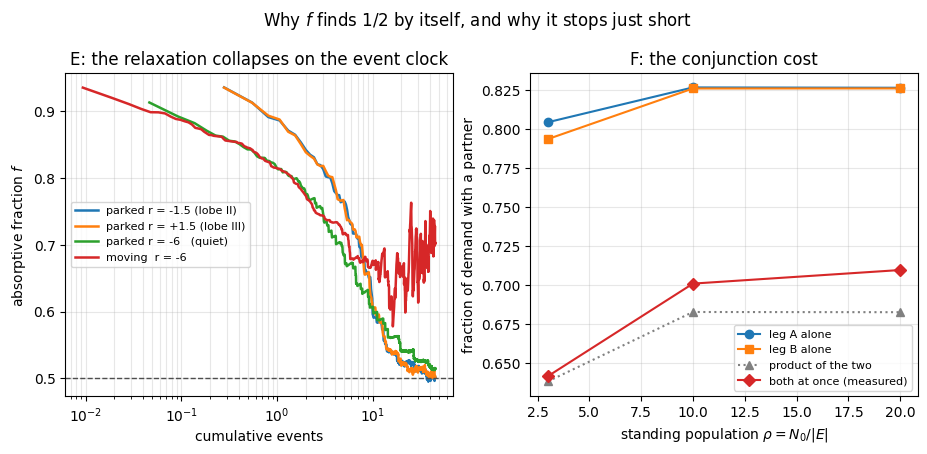

In [11]:
def fig_thermostat(traces, frows):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    for tag, rows in traces:
        ax[0].plot(rows[:, 0], rows[:, 1], lw=1.8, label=tag.strip())
    ax[0].axhline(0.5, ls="--", color="0.3", lw=1)
    ax[0].set_xscale("log")
    ax[0].set_xlabel("cumulative events")
    ax[0].set_ylabel(r"absorptive fraction $f$")
    ax[0].set_title("E: the relaxation collapses on the event clock")
    ax[0].legend(fontsize=8)
    ax[0].grid(alpha=.3, which="both")

    rho = [r[0] for r in frows]
    ax[1].plot(rho, [r[1] for r in frows], "o-", label="leg A alone")
    ax[1].plot(rho, [r[2] for r in frows], "s-", label="leg B alone")
    ax[1].plot(rho, [r[4] for r in frows], "^:", color="0.5",
               label="product of the two")
    ax[1].plot(rho, [r[3] for r in frows], "D-", color="C3",
               label="both at once (measured)")
    ax[1].set_xlabel(r"standing population $\rho = N_0/|E|$")
    ax[1].set_ylabel("fraction of demand with a partner")
    ax[1].set_title("F: the conjunction cost")
    ax[1].legend(fontsize=8)
    ax[1].grid(alpha=.3)
    fig.suptitle("Why $f$ finds $1/2$ by itself, and why it stops "
                 "just short", y=1.03)
    save_fig(fig, "emission_absorption_thermostat.png")

fig_thermostat(traces, frows)

Either leg on its own finds its partner about four times in five. Requiring
both at once drops that to about two in three. Absorption is rationed by
whichever leg is harder, and the resulting deficit is the **conjunction cost**.

**What this does not show.** The project has elsewhere attributed the
conjunction cost to strong *anti-correlation* between the two legs'
availability. These numbers give that no support: the joint figure sits
slightly below the product at $\rho = 3$ and slightly *above* it at
$\rho = 10$ and $20$. A mean of a minimum against a product of means is not
a correlation test, so this refutes nothing — but it establishes nothing
either, and the explanation should be treated as open until measured properly.
Logged as **J-SP1**.

What *is* established is simpler and enough for a tutorial: requiring two
things at once is harder than requiring one, and that is where the shortfall
comes from.

---


## 9. The objection a careful reader will raise

> *If no world-particle ever changes its momentum discontinuously, how can
> ionising a sea pair at row $p$ put its two constituents at rows
> $p \pm \xi_q$? Surely that is exactly a discontinuous momentum change — and
> for two bodies at once.*

It certainly looks like one. The bound pair sits at row $p$; its two constituents
end up at rows $p \pm \xi_q$. If those constituents were world-particles
with momenta of their own, those momenta just changed discontinuously.

The resolution is §2's careful sentence. A bound sea pair is *one* neutral
object, not two world-particles. Its constituents have no worldlines while
bound. What happens at an emissive event is that two worldlines **begin**, at
$p + \xi_q$ and $p - \xi_q$ respectively. A worldline that begins at a
momentum has not moved to that momentum. Birth is not a velocity change.

Symmetrically, at an absorptive event two worldlines **end**, and a neutral
object appears at the parent row. The bodies were not carried to $p$; they
ceased to be bodies.

This is why the space-time figure of §4 is the one to trust and the phase-space
cartoon is the one to be careful with. In space-time the two lines fork out of a
point. The phase-space picture, read carelessly, draws horizontal segments
connecting momentum rows — exactly the transport that does not happen.

Momentum still balances: the pair at $p$ carries $2p$, and the daughters
carry $(p + \xi_q) + (p - \xi_q) = 2p$. In the space-time picture that is
just the statement that the parent's slope is the mean of the daughters'.

The same reading disposes of a related worry. One might ask what *holds* a sea
pair together, given that the project admits no new forces. Nothing does, in
the sense of a binding force. A bound pair is a single neutral member of a
third population; it is not a composite held in place by an interaction. Its
constituents are not two things that have been joined, which is why they have
no separate worldlines to be joined along.

---


## 10. What is excluded, and why

Two further readings are available and both are ruled out.

**Settling the two legs differently.** Pay one leg by creating a body and the
other by removing one. The deposition in $E$ is still correct. But count the
bodies: one has appeared at one daughter row and one has disappeared at the
other, and the difference has to have been carried between two momentum rows
separated by $2\xi_q$. Nothing can carry it. A world-particle would have had
to move — a **hop**, not a jump — and individual body-momentum conservation
fails. The realisation is therefore a property of the **event**, not of a leg.

In space-time the reason is immediate: a mixed realisation would have one
worldline beginning at one daughter row and another ending at the other, with
nothing connecting them, and the momentum books would not close. A pair is
either coming apart or coming together. It cannot do half of each.

**Relocating a body instead of pairing.** The third channel, in which a body is
simply moved from one row to another, is genuinely available and is analysed
elsewhere in the project. It relaxes the "both daughters" requirement of §8
from a conjunction to a disjunction, which helps the supply problem — at the
cost of individual body-momentum conservation, which is the thing the ontology
exists to protect. It is not part of the specified algorithm.

---


## 11. Numerical verification

All figures and tables above are produced by
[`src/demo_emission_and_absorption.py`](../../src/demo_emission_and_absorption.py):

| part | what it establishes |
|---|---|
| A | $K_{\mathrm{res}}$ real, odd, moving neither worlds nor momentum; $(q, -q)$ is one event |
| — | four figures, including the space-time worldlines of §4 |
| B | the two realisations agree in $E$ and differ in the populations, with $\Delta N/\Delta S = -2$ exactly |
| C | both species move together; $\Delta N = 2(1-2f)n$ to $1.5 \times 10^{-14}$ |
| D | J1 exact to $3.5\times10^{-16}$ globally; J2, local violation $4\times10^{9}$ larger |
| E | the relaxation of $f$ collapses on the event clock across four rate regimes |
| F | the conjunction cost, and the withdrawal of the anti-correlation claim (J-SP1) |
| G | the observable's independence from the populations is $O(\Delta t)$; see J-SP2 |

Run as:

```
WPMW_OUTPUT=... PYTHONPATH=src python3 src/demo_emission_and_absorption.py
```

---


## 12. Open items

### J-SP1 — the conjunction cost is measured, its explanation is not

§8 establishes the cost. The project has elsewhere attributed it to strong
*anti-correlation* between the two legs' partner availability, and these
numbers give that no support: the joint figure sits slightly below the product
of the two single-leg figures at $\rho = 3$ and slightly **above** it at
$\rho = 10$ and $20$. A mean of a minimum against a product of means is not
a correlation test, so nothing is refuted — but nothing is established either.
A proper test would correlate the two caps directly at fixed demand.

### J-SP2 — a proposed change to the allocation loop

**This is a separate subject from the tutorial and is recorded here only so it
is not lost.** It is a proposal for the maintainer's judgement, not a finding
about the ontology.

§5.1 of the specification requires $u^{\pm} \ge 0$ pointwise and clamps after
every allocation. That clamp is the only operation in the specified world form
that can break Theorem J1. Part D of the demo runs every case both ways —
see the same live table in §5 above, which already includes both `clamp`
values.

With the clamp on, J1 degrades from machine precision to $10^{-7}$ and the
two species stop moving together at $10^{-4}$.

Part G is the sharper measurement. It prepares the same $W$ at $\rho = 1$
and $\rho = 20$ — twenty times as many bodies, identical $E$ — and asks how
far apart the two observables have drifted at $t = 2$ — executed live
below (part G).


In [12]:
def part_g(run):
    banner("G. Nothing in the ledger reaches the observable")
    e0 = packet(run)
    T = 2.0
    print("   Padding the ensemble raises N twentyfold and leaves E alone at")
    print("   t = 0.  How far apart are the two observables at t = 2?")
    print(f"   {'dt':>8}{'clamp off':>14}{'ratio':>8}"
          f"{'clamp on':>14}{'ratio':>8}")
    rows = []
    prev = {False: None, True: None}
    cols = {False: [], True: []}
    for dt in (0.02, 0.01, 0.005):
        line = f"   {dt:>8.3f}"
        for clamp in (False, True):
            outs = []
            for rho in (1.0, 20.0):
                up, um, sea = run.prepare(e0, rho)
                for _ in range(int(round(T / dt))):
                    up, um, sea = run.stream3(up, um, sea, .5 * dt)
                    up, um, sea, _, _ = run.channels(up, um, sea, dt,
                                                     clamp=clamp)
                    up, um, sea = run.stream3(up, um, sea, .5 * dt)
                outs.append(up - um)
            d = float(np.linalg.norm(outs[1] - outs[0])
                      / np.linalg.norm(outs[0]))
            cols[clamp].append(d)
            line += f"{d:>14.4e}"
            line += ("        " if prev[clamp] is None
                     else f"{prev[clamp] / d:>8.2f}")
            prev[clamp] = d
        rows.append((dt, cols[False][-1], cols[True][-1]))
        print(line)
    print()
    print("   Clamp off, the difference halves cleanly with dt: it is the")
    print("   allocation error of the tau-leap, amplified by N/||E||, and it")
    print("   converges to zero.  In the continuum the observable does not")
    print("   know how the ledger settled its events -- which is the whole")
    print("   force of Theorem S2.")
    print("   Clamp on, it stalls near 1e-2 and does not converge.  See")
    print("   open item J-SP2.")
    return rows

grows = part_g(run)


G. Nothing in the ledger reaches the observable
   Padding the ensemble raises N twentyfold and leaves E alone at
   t = 0.  How far apart are the two observables at t = 2?
         dt     clamp off   ratio      clamp on   ratio


      0.020    2.6256e-03            2.0813e-02        


      0.010    1.3112e-03    2.00    2.1697e-02    0.96


      0.005    6.5516e-04    2.00    2.2122e-02    0.98

   Clamp off, the difference halves cleanly with dt: it is the
   allocation error of the tau-leap, amplified by N/||E||, and it
   converges to zero.  In the continuum the observable does not
   know how the ledger settled its events -- which is the whole
   force of Theorem S2.
   Clamp on, it stalls near 1e-2 and does not converge.  See
   open item J-SP2.


**Program note.** The ledger figure's left panel is Part D's global-vs-local
comparison from §5 above; its right panel is Part G's clamp on/off
convergence check, just computed. As with the thermostat figure, the
combined image only exists once both are in hand.


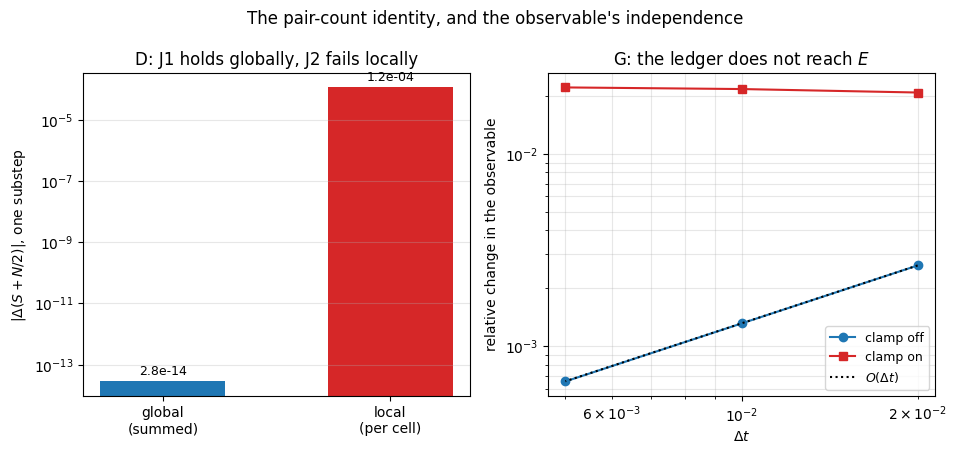

In [13]:
def fig_ledger(glob, loc, tot, grows):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    labels = ["global\n(summed)", "local\n(per cell)"]
    ax[0].bar(labels, [tot, loc], color=["C0", "C3"], width=.55)
    ax[0].set_yscale("log")
    ax[0].set_ylabel(r"$|\Delta(S + N/2)|$, one substep")
    ax[0].set_title("D: J1 holds globally, J2 fails locally")
    ax[0].grid(alpha=.3, axis="y", which="both")
    for i, v in enumerate([tot, loc]):
        ax[0].text(i, v * 1.6, f"{v:.1e}", ha="center", fontsize=9)

    dts = np.array([r[0] for r in grows])
    ds = np.array([r[1] for r in grows])
    dc = np.array([r[2] for r in grows])
    ax[1].loglog(dts, ds, "o-", color="C0", label="clamp off")
    ax[1].loglog(dts, dc, "s-", color="C3", label="clamp on")
    ax[1].loglog(dts, ds[0] * dts / dts[0], "k:", label=r"$O(\Delta t)$")
    ax[1].set_xlabel(r"$\Delta t$")
    ax[1].set_ylabel("relative change in the observable")
    ax[1].set_title("G: the ledger does not reach $E$")
    ax[1].legend(fontsize=9)
    ax[1].grid(alpha=.3, which="both")
    fig.suptitle("The pair-count identity, and the observable's independence",
                 y=1.03)
    save_fig(fig, "emission_absorption_ledger.png")

fig_ledger(glob, loc, tot, grows)

Clamp off, the difference halves cleanly with $\Delta t$ — it is tau-leap
allocation error amplified by $N/\|E\|$, and it converges to zero, which is
what the theory requires. Clamp on, it stalls near $10^{-2}$ and does not
converge at all.

**Diagnosis.** The clamp is not repairing an over-drawn allocation. The partner
caps are read live and clipped at zero, so the allocation never over-draws. It
is repairing the small negative populations that **spectral transport** leaves
behind through ringing — a transport artefact, repaired inside the event loop,
where it corrupts event arithmetic that is otherwise exact.  (This is the same
Part G computation used for the ledger figure after §8 above.)

**Proposal, for judgement.** Clip the partner **caps** at zero inside the
allocation — local, physically obvious, since a negative supply is no supply,
and it leaves the population arithmetic exact — and let transport ringing be
repaired at the transport substep, where the specification already mandates a
separate repair restoring $N \ge |E|$.

**Status: independently confirmed, and the proposal is the whole proposal.**
Part J of [`../analysis/sea_population_equilibrium.md`](../analysis/sea_population_equilibrium.md)
runs all three variants at $T = 8$, $\Delta t = 0.02$ and reads the
shortfall through S7:

| variant | $\tfrac{1}{2}-f$ | ledger gap |
|---|---|---|
| as specified | $+0.0440$ | $5\times10^{-17}$ |
| caps clipped, clamp kept | $-0.1040$ | $9\times10^{-2}$ |
| J-SP2: caps clipped, clamp removed | $+0.0079$ | $4\times10^{-15}$ |

Doing half of it is worse than doing none: clipping the caps starves the
allocation of the negative supply it had been drawing on, the population clamp
fires to make up the difference, and S7 parts by $9\times10^{-2}$. Doing both
halves keeps S7 at machine precision and cuts the shortfall fivefold. The
channel decomposition says why the effect is so concentrated: $q = 1$ carries
about 56 per cent of all demand, and its absorptive fraction is nonsensical —
$-15.8$ at the coarse end of the reach ladder — wherever the negative caps
dominate. Logged from that side as S-SP7.

**A corollary worth flagging separately.** The specification's own consistency
test reads a ledger residual above the floor as evidence that an implementation
has admitted a hop. On this measurement it can equally mean the clamp is
firing. That test may need a second named failure mode.

### Untouched here

The local sea level is a live dynamical variable in a genuinely two-field
system (§5.2). What it does — whether it supports oscillation or travelling
structure, and how the free and bound populations exchange locally rather than
in total — is not addressed by this note.

---


## 13. Where to go next

- [`compensated_liouville_algorithm.md`](../algorithm/compensated_liouville_algorithm.md)
  §5 — the normative specification this note unpacks.
- [`compensated_liouville_splitting.md`](../analysis/compensated_liouville_splitting.md)
  — where the residual channel comes from: the exact removal of the classical
  force, and why something is left over afterwards. The right note to read
  first if §3 above went too fast.
- [`sea_population_equilibrium.md`](../analysis/sea_population_equilibrium.md)
  — the derivation, the failure of emissive-only unravelling, and the attractor
  result.
- [`species_sectors_and_annihilation.md`](../analysis/species_sectors_and_annihilation.md)
  — what the sea is, and why the dark bound pair is not the crystal shift.
- [`eckart_barrier_compensated.md`](../analysis/eckart_barrier_compensated.md)
  §8 — what all this looks like as tunnelling.


---

## Notebook provenance

This notebook was generated and executed by Claude from the two canonical
source files named above, as a companion rendering rather than a
replacement. It carries the same license as the rest of `docs/`
(CC-BY-SA-4.0); the underlying code it reproduces is licensed separately
under AGPL-3.0-or-later (see the repository README).

A rendered copy of this notebook, with all outputs and figures intact,
lives on the `output` branch at `notebooks/emission_and_absorption.ipynb`.
The copy on `main`, in `docs/notebooks/emission_and_absorption.ipynb`, has
its outputs stripped so that future patches to it stay reviewable as
plain-text diffs.
